In [1]:
# ── CELL 1: Set up project structure and locate source SMILES files ──

from pathlib import Path
import subprocess

PROJECT_ROOT = Path.home() / "admet_project"
PROJECT_ROOT.mkdir(exist_ok=True)
(PROJECT_ROOT / "results").mkdir(exist_ok=True)

# Locate source files on the Windows side
result = subprocess.run(
    ["find", "/mnt/c/my_projects_all/portfolio_projects/Msc_project/data",
     "-iname", "md_shortlist.csv", "-o", "-iname", "docking_results.csv",
     "-o", "-iname", "vs_docking_shortlist.csv"],
    capture_output=True, text=True, timeout=30,
)
print(result.stdout)
print(result.stderr)

/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/docking_results.csv
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/md_shortlist.csv
/mnt/c/my_projects_all/portfolio_projects/Msc_project/data/vs_docking_shortlist.csv




In [2]:
# ── CELL 2: Inspect column structure of all three source files ──

import pandas as pd

DATA_DIR = Path("/mnt/c/my_projects_all/portfolio_projects/Msc_project/data")

md_shortlist = pd.read_csv(DATA_DIR / "md_shortlist.csv")
docking_results = pd.read_csv(DATA_DIR / "docking_results.csv")
vs_docking_shortlist = pd.read_csv(DATA_DIR / "vs_docking_shortlist.csv")

print("=== md_shortlist.csv ===")
print(f"Shape: {md_shortlist.shape}")
print(f"Columns: {list(md_shortlist.columns)}")
print(md_shortlist.head(10))

print("\n=== docking_results.csv ===")
print(f"Shape: {docking_results.shape}")
print(f"Columns: {list(docking_results.columns)}")
print(docking_results.head(5))

print("\n=== vs_docking_shortlist.csv ===")
print(f"Shape: {vs_docking_shortlist.shape}")
print(f"Columns: {list(vs_docking_shortlist.columns)}")
print(vs_docking_shortlist.head(5))

=== md_shortlist.csv ===
Shape: (5, 15)
Columns: ['dock_id', 'identifier', 'canonical_smiles', 'p_active', 'is_african_np', 'vina_score_1', 'vina_score_2', 'vina_score_3', 'n_modes', 'dock_time_s', 'dock_ok', 'out_pdbqt', 'docking_rank', 'np_classifier_pathway', 'md_rank']
        dock_id    identifier  \
0  CNP0286261_0  CNP0286261.0   
1  CNP0275186_1  CNP0275186.1   
2  CNP0319845_2  CNP0319845.2   
3  CNP0178940_1  CNP0178940.1   
4  CNP0539885_2  CNP0539885.2   

                                    canonical_smiles  p_active  is_african_np  \
0  O=C(CCc1ccccc1)c1c(O)c(Cc2ccccc2O)c2c(c1O)Cc1c...  0.355169           True   
1  CC(C)C1=CC2=CC=C3[C@@](C)(COC(=O)c4ccc(O)c(O)c...  0.328379           True   
2  COc1cc2c(cc1OC)[C@@H]1C(=O)c3ccc4c(c3O[C@@H]1C...  0.300618           True   
3  COc1ccc([C@H](CC(=O)O)NC(=O)COc2cc(O)c3c(c2)OC...  0.507530          False   
4  N=c1nc(O)c2c(CCc3ccc(C(=O)N[C@@H](CCC(=O)O)C(=...  0.615487          False   

   vina_score_1  vina_score_2  vina_scor

In [3]:
# ── CELL 3: Extract and consolidate the compound set for ADMET profiling ──

top10_docking = docking_results.sort_values("docking_rank").head(10)[
    ["dock_id", "canonical_smiles", "vina_score_1", "docking_rank"]
].copy()
top10_docking["source"] = "top10_docking"

md_compounds = md_shortlist[
    ["dock_id", "canonical_smiles", "vina_score_1", "md_rank"]
].copy()
md_compounds["source"] = "md_shortlist"
md_compounds = md_compounds.rename(columns={"md_rank": "docking_rank"})

combined = pd.concat([top10_docking, md_compounds], ignore_index=True)

# Deduplicate by dock_id, keeping the first occurrence (prioritising top10_docking source label)
combined = combined.drop_duplicates(subset="dock_id", keep="first").reset_index(drop=True)

# Add pyrimethamine as reference
pyrimethamine_row = pd.DataFrame([{
    "dock_id": "pyrimethamine",
    "canonical_smiles": "Cc1cnc(N)nc1-c1ccc(Cl)cc1",
    "vina_score_1": -6.90,
    "docking_rank": None,
    "source": "reference_drug",
}])
combined = pd.concat([combined, pyrimethamine_row], ignore_index=True)

print(f"Total unique compounds for ADMET profiling: {len(combined)}")
print(combined[["dock_id", "source", "docking_rank"]].to_string(index=False))

combined.to_csv(PROJECT_ROOT / "admet_compound_list.csv", index=False)
print(f"\nSaved to: {PROJECT_ROOT / 'admet_compound_list.csv'}")

Total unique compounds for ADMET profiling: 13
      dock_id         source docking_rank
 CNP0286261_0  top10_docking            1
 CNP0275186_1  top10_docking            2
 CNP0319845_2  top10_docking            3
 CNP0110434_2  top10_docking            4
 CNP0346362_1  top10_docking            5
 CNP0346376_1  top10_docking            6
 CNP0329927_1  top10_docking            7
 CNP0332712_1  top10_docking            8
 CNP0309710_3  top10_docking            9
 CNP0242596_0  top10_docking           10
 CNP0178940_1   md_shortlist            4
 CNP0539885_2   md_shortlist            5
pyrimethamine reference_drug         None

Saved to: /home/kenjo/admet_project/admet_compound_list.csv


In [4]:
# ── CELL 4: Run ADMET-AI predictions on the full compound set ──

from admet_ai import ADMETModel

model = ADMETModel()

smiles_list = combined["canonical_smiles"].tolist()
dock_ids = combined["dock_id"].tolist()

print(f"Running ADMET-AI on {len(smiles_list)} compounds...")
predictions = model.predict(smiles=smiles_list)

print(f"\nPrediction shape: {predictions.shape}")
print(f"Columns ({len(predictions.columns)}): {list(predictions.columns)[:15]}...")

# Attach compound identifiers
predictions.insert(0, "dock_id", dock_ids)

predictions.to_csv(PROJECT_ROOT / "results" / "admet_predictions_raw.csv", index=False)
print(f"\nSaved to: {PROJECT_ROOT / 'results' / 'admet_predictions_raw.csv'}")

print("\n--- Preview ---")
print(predictions.head(3))

/home/kenjo/miniforge3/envs/admet/lib/python3.10/site-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location=lambda

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

/home/kenjo/miniforge3/envs/admet/lib/python3.10/site-packages/chemprop/utils.py:418: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=lam

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]










model ensembles:  50%|█████     | 1/2 [00:00<00:00,  1.44it/s]









model ensembles: 100%|██████████| 2/2 [00:01<00:00,  1.72it/s]



Prediction shape: (13, 98)
Columns (98): ['molecular_weight', 'logP', 'hydrogen_bond_acceptors', 'hydrogen_bond_donors', 'Lipinski', 'QED', 'stereo_centers', 'tpsa', 'AMES', 'BBB_Martins', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith']...

Saved to: /home/kenjo/admet_project/results/admet_predictions_raw.csv

--- Preview ---
                                                         dock_id  \
O=C(CCc1ccccc1)c1c(O)c(Cc2ccccc2O)c2c(c1O)Cc1cc...  CNP0286261_0   
CC(C)C1=CC2=CC=C3[C@@](C)(COC(=O)c4ccc(O)c(O)c4...  CNP0275186_1   
COc1cc2c(cc1OC)[C@@H]1C(=O)c3ccc4c(c3O[C@@H]1CO...  CNP0319845_2   

                                                    molecular_weight    logP  \
O=C(CCc1ccccc1)c1c(O)c(Cc2ccccc2O)c2c(c1O)Cc1cc...           452.506  5.9062   
CC(C)C1=CC2=CC=C3[C@@](C)(COC(=O)c4ccc(O)c(O)c4...           450.531  5.2947   
COc1cc2c(cc1OC)[C@@H]1C(=O)c3ccc4c(c3O[C@@H]1CO...           394.423  4.0079   

                    

In [5]:
# ── CELL 5: Print full column list and clean up the index ──

predictions_clean = predictions.reset_index(drop=True)

print(f"Total columns: {len(predictions_clean.columns)}\n")
for i, col in enumerate(predictions_clean.columns):
    print(f"{i}: {col}")

Total columns: 99

0: dock_id
1: molecular_weight
2: logP
3: hydrogen_bond_acceptors
4: hydrogen_bond_donors
5: Lipinski
6: QED
7: stereo_centers
8: tpsa
9: AMES
10: BBB_Martins
11: Bioavailability_Ma
12: CYP1A2_Veith
13: CYP2C19_Veith
14: CYP2C9_Substrate_CarbonMangels
15: CYP2C9_Veith
16: CYP2D6_Substrate_CarbonMangels
17: CYP2D6_Veith
18: CYP3A4_Substrate_CarbonMangels
19: CYP3A4_Veith
20: Carcinogens_Lagunin
21: ClinTox
22: DILI
23: HIA_Hou
24: NR-AR-LBD
25: NR-AR
26: NR-AhR
27: NR-Aromatase
28: NR-ER-LBD
29: NR-ER
30: NR-PPAR-gamma
31: PAMPA_NCATS
32: Pgp_Broccatelli
33: SR-ARE
34: SR-ATAD5
35: SR-HSE
36: SR-MMP
37: SR-p53
38: Skin_Reaction
39: hERG
40: Caco2_Wang
41: Clearance_Hepatocyte_AZ
42: Clearance_Microsome_AZ
43: Half_Life_Obach
44: HydrationFreeEnergy_FreeSolv
45: LD50_Zhu
46: Lipophilicity_AstraZeneca
47: PPBR_AZ
48: Solubility_AqSolDB
49: VDss_Lombardo
50: molecular_weight_drugbank_approved_percentile
51: logP_drugbank_approved_percentile
52: hydrogen_bond_acceptors_dr

In [6]:
# ── CELL 6: Organise predictions into ADME-Tox categories and flag toxicity risks ──

# Category groupings based on ADMET-AI's documented panel
absorption_cols = ["HIA_Hou", "Caco2_Wang", "PAMPA_NCATS", "Pgp_Broccatelli", "Bioavailability_Ma"]
distribution_cols = ["BBB_Martins", "VDss_Lombardo", "PPBR_AZ"]
metabolism_cols = ["CYP1A2_Veith", "CYP2C19_Veith", "CYP2C9_Veith", "CYP2D6_Veith", "CYP3A4_Veith",
                   "CYP2C9_Substrate_CarbonMangels", "CYP2D6_Substrate_CarbonMangels", "CYP3A4_Substrate_CarbonMangels"]
excretion_cols = ["Clearance_Hepatocyte_AZ", "Clearance_Microsome_AZ", "Half_Life_Obach"]
toxicity_binary_cols = ["AMES", "DILI", "hERG", "ClinTox", "Carcinogens_Lagunin", "Skin_Reaction",
                         "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase", "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma",
                         "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"]
toxicity_continuous_cols = ["LD50_Zhu", "Lipophilicity_AstraZeneca", "Solubility_AqSolDB"]

# Flag toxicity risks using standard 0.5 threshold for binary endpoints
flag_df = predictions_clean[["dock_id"] + toxicity_binary_cols].copy()
for col in toxicity_binary_cols:
    flag_df[col] = (flag_df[col] >= 0.5).astype(int)
flag_df["total_flags"] = flag_df[toxicity_binary_cols].sum(axis=1)

print("=== Toxicity flag summary (count of endpoints >= 0.5 probability) ===")
print(flag_df[["dock_id", "total_flags"]].sort_values("total_flags").to_string(index=False))

print("\n=== hERG, AMES, DILI raw probabilities (most commonly reported in ADMET papers) ===")
key_tox = predictions_clean[["dock_id", "hERG", "AMES", "DILI", "ClinTox"]].copy()
print(key_tox.sort_values("dock_id").to_string(index=False))

print("\n=== Key physicochemical and absorption properties ===")
key_props = predictions_clean[["dock_id", "molecular_weight", "logP", "QED", "Lipinski",
                                 "HIA_Hou", "Caco2_Wang", "BBB_Martins",
                                 "Solubility_AqSolDB_drugbank_approved_percentile"]].copy()
print(key_props.sort_values("dock_id").to_string(index=False))

flag_df.to_csv(PROJECT_ROOT / "results" / "toxicity_flags.csv", index=False)
key_tox.to_csv(PROJECT_ROOT / "results" / "key_toxicity_endpoints.csv", index=False)
print(f"\nSaved toxicity summaries to {PROJECT_ROOT / 'results'}")

=== Toxicity flag summary (count of endpoints >= 0.5 probability) ===
      dock_id  total_flags
 CNP0178940_1            1
pyrimethamine            1
 CNP0539885_2            2
 CNP0110434_2            3
 CNP0346376_1            3
 CNP0286261_0            4
 CNP0319845_2            4
 CNP0329927_1            4
 CNP0332712_1            4
 CNP0309710_3            4
 CNP0275186_1            5
 CNP0346362_1            6
 CNP0242596_0            7

=== hERG, AMES, DILI raw probabilities (most commonly reported in ADMET papers) ===
      dock_id     hERG     AMES     DILI  ClinTox
 CNP0110434_2 0.445055 0.077657 0.605422 0.023582
 CNP0178940_1 0.113965 0.250999 0.725869 0.192354
 CNP0242596_0 0.846573 0.438901 0.919745 0.089550
 CNP0275186_1 0.535028 0.261342 0.579984 0.053568
 CNP0286261_0 0.816977 0.176554 0.772525 0.012658
 CNP0309710_3 0.454912 0.174909 0.639482 0.029491
 CNP0319845_2 0.597809 0.246848 0.875874 0.071252
 CNP0329927_1 0.958806 0.527387 0.363167 0.591308
 CNP0332712_1 0.5

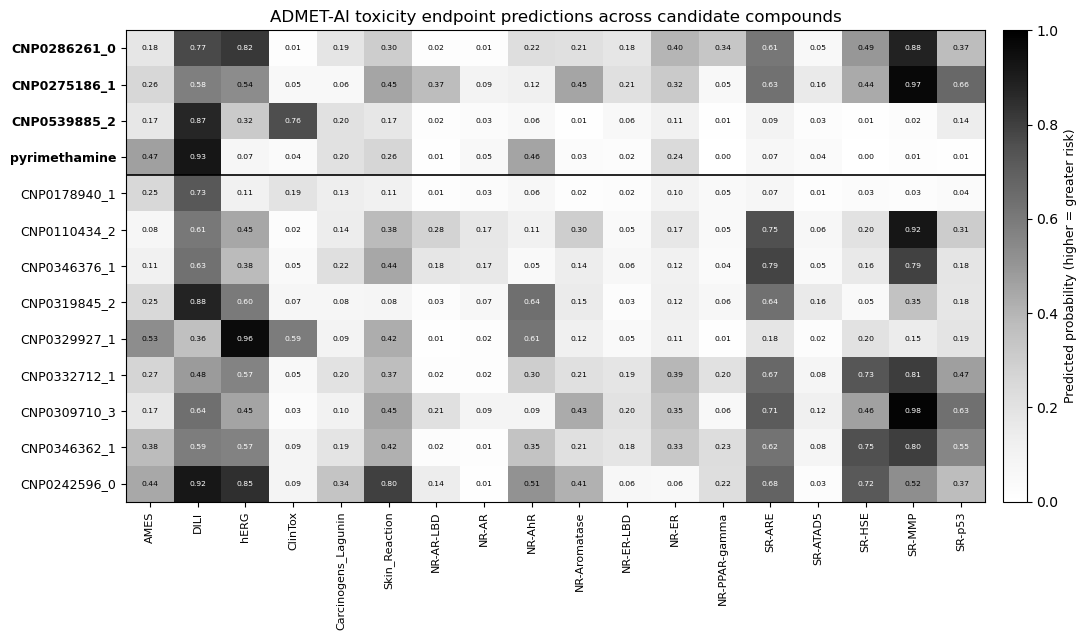

Saved to: /home/kenjo/admet_project/figures/fig_toxicity_heatmap.png


In [7]:
# ── CELL 7: Build the toxicity endpoint heatmap ──

import matplotlib.pyplot as plt
import numpy as np

heatmap_cols = toxicity_binary_cols  # 18 binary endpoints from Cell 6

heatmap_data = predictions_clean.set_index("dock_id")[heatmap_cols]

# Order: MM-PBSA leads and pyrimethamine first, then remaining docking hits by total flags
priority_order = ["CNP0286261_0", "CNP0275186_1", "CNP0539885_2", "pyrimethamine"]
remaining = [c for c in heatmap_data.index if c not in priority_order]
remaining_sorted = flag_df.set_index("dock_id").loc[remaining].sort_values("total_flags").index.tolist()
row_order = priority_order + remaining_sorted

heatmap_data = heatmap_data.loc[row_order]

fig, ax = plt.subplots(figsize=(11, 6.5))

im = ax.imshow(heatmap_data.values, cmap="Greys", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(row_order, fontsize=9)

# Bold labels for the four priority compounds
for i, label in enumerate(ax.get_yticklabels()):
    if row_order[i] in priority_order:
        label.set_fontweight("bold")

# Draw a separating line between priority compounds and the rest
ax.axhline(len(priority_order) - 0.5, color="black", linewidth=1.2)

# Annotate cell values
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        text_color = "white" if val > 0.55 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=5.5, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Predicted probability (higher = greater risk)", fontsize=9)

ax.set_title("ADMET-AI toxicity endpoint predictions across candidate compounds", fontsize=12)
plt.tight_layout()

output_path = PROJECT_ROOT / "figures" / "fig_toxicity_heatmap.png"
output_path.parent.mkdir(exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path}")

In [8]:
# ── CELL 8: Identify the single most severe endpoint per priority compound ──

for compound in priority_order:
    row = predictions_clean.set_index("dock_id").loc[compound, toxicity_binary_cols]
    worst_endpoint = row.idxmax()
    worst_value = row.max()
    print(f"{compound}: highest-risk endpoint = {worst_endpoint} ({worst_value:.2f})")

CNP0286261_0: highest-risk endpoint = SR-MMP (0.88)
CNP0275186_1: highest-risk endpoint = SR-MMP (0.97)
CNP0539885_2: highest-risk endpoint = DILI (0.87)
pyrimethamine: highest-risk endpoint = DILI (0.93)


In [9]:
# ── CELL 9: Build the compact liability summary table ──

liability_rows = []
for compound in predictions_clean["dock_id"]:
    row = predictions_clean.set_index("dock_id").loc[compound, toxicity_binary_cols]
    worst_endpoint = row.idxmax()
    worst_value = row.max()
    n_flags = flag_df.set_index("dock_id").loc[compound, "total_flags"]
    liability_rows.append({
        "Compound": compound,
        "Highest-risk endpoint": worst_endpoint,
        "Probability": round(worst_value, 2),
        "Total flags (>=0.5)": int(n_flags),
    })

liability_df = pd.DataFrame(liability_rows)

# Order: priority compounds first, then remaining by total flags ascending
liability_df["priority"] = liability_df["Compound"].isin(priority_order)
liability_df = liability_df.sort_values(
    by=["priority", "Total flags (>=0.5)"], ascending=[False, True]
).drop(columns="priority").reset_index(drop=True)

liability_df["Compound"] = liability_df["Compound"].replace({
    "CNP0286261_0": "CNP0286261",
    "CNP0275186_1": "CNP0275186",
    "CNP0539885_2": "CNP0539885",
    "pyrimethamine": "Pyrimethamine (reference)",
})

print(liability_df.to_string(index=False))

liability_df.to_csv(PROJECT_ROOT / "results" / "table2_liability_summary.csv", index=False)
print(f"\nSaved to: {PROJECT_ROOT / 'results' / 'table2_liability_summary.csv'}")

                 Compound Highest-risk endpoint  Probability  Total flags (>=0.5)
Pyrimethamine (reference)                  DILI         0.93                    1
               CNP0539885                  DILI         0.87                    2
               CNP0286261                SR-MMP         0.88                    4
               CNP0275186                SR-MMP         0.97                    5
             CNP0178940_1                  DILI         0.73                    1
             CNP0110434_2                SR-MMP         0.92                    3
             CNP0346376_1                SR-MMP         0.79                    3
             CNP0319845_2                  DILI         0.88                    4
             CNP0329927_1                  hERG         0.96                    4
             CNP0332712_1                SR-MMP         0.81                    4
             CNP0309710_3                SR-MMP         0.98                    4
             CNP

In [10]:
# ── CELL 10: Build the ADME summary table for the four priority compounds ──

adme_props = {
    "HIA (%)": ("HIA_Hou", None),
    "Caco2 permeability": ("Caco2_Wang", "Caco2_Wang_drugbank_approved_percentile"),
    "Oral bioavailability": ("Bioavailability_Ma", None),
    "P-gp substrate": ("Pgp_Broccatelli", None),
    "BBB penetration": ("BBB_Martins", None),
    "Plasma protein binding": ("PPBR_AZ", "PPBR_AZ_drugbank_approved_percentile"),
    "Volume of distribution": ("VDss_Lombardo", "VDss_Lombardo_drugbank_approved_percentile"),
    "CYP1A2 inhibition": ("CYP1A2_Veith", None),
    "CYP2C9 inhibition": ("CYP2C9_Veith", None),
    "CYP2C19 inhibition": ("CYP2C19_Veith", None),
    "CYP2D6 inhibition": ("CYP2D6_Veith", None),
    "CYP3A4 inhibition": ("CYP3A4_Veith", None),
    "Hepatocyte clearance": ("Clearance_Hepatocyte_AZ", "Clearance_Hepatocyte_AZ_drugbank_approved_percentile"),
    "Microsomal clearance": ("Clearance_Microsome_AZ", "Clearance_Microsome_AZ_drugbank_approved_percentile"),
    "Half-life": ("Half_Life_Obach", "Half_Life_Obach_drugbank_approved_percentile"),
}

pred_indexed = predictions_clean.set_index("dock_id")

adme_rows = []
for label, (raw_col, pct_col) in adme_props.items():
    row = {"Property": label}
    for compound in priority_order:
        raw_val = pred_indexed.loc[compound, raw_col]
        if pct_col:
            pct_val = pred_indexed.loc[compound, pct_col]
            row[compound] = f"{raw_val:.2f} ({pct_val:.0f}th pctl)"
        else:
            row[compound] = f"{raw_val:.2f}"
    adme_rows.append(row)

adme_table = pd.DataFrame(adme_rows)
adme_table = adme_table.rename(columns={
    "CNP0286261_0": "CNP0286261",
    "CNP0275186_1": "CNP0275186",
    "CNP0539885_2": "CNP0539885",
    "pyrimethamine": "Pyrimethamine",
})

print(adme_table.to_string(index=False))

adme_table.to_csv(PROJECT_ROOT / "results" / "table3_ADME_summary.csv", index=False)
print(f"\nSaved to: {PROJECT_ROOT / 'results' / 'table3_ADME_summary.csv'}")

              Property         CNP0286261         CNP0275186         CNP0539885     Pyrimethamine
               HIA (%)               1.00               1.00               0.22              1.00
    Caco2 permeability  -5.30 (32th pctl)  -5.06 (45th pctl)   -6.74 (4th pctl) -4.41 (86th pctl)
  Oral bioavailability               0.59               0.47               0.66              0.99
        P-gp substrate               0.98               0.77               0.04              0.01
       BBB penetration               0.11               0.44               0.37              0.97
Plasma protein binding 103.44 (95th pctl) 110.72 (99th pctl)  75.30 (50th pctl) 89.08 (72th pctl)
Volume of distribution   3.82 (67th pctl)   6.89 (84th pctl)   3.86 (67th pctl)  7.89 (87th pctl)
     CYP1A2 inhibition               0.50               0.39               0.06              0.85
     CYP2C9 inhibition               0.94               0.56               0.07              0.01
    CYP2C19 inhibiti